# Discover biases in metrics by site
---

While dealing with multisite data, we need to be careful when reporting our metrics.

Performance metrics give us an overall idea of the model's performance across all samples (subjects). However, there might be hidden biases in our data that these metrics might overlook.

In these exercises, besides computing the overall metric, we will compute each of the metrics, but using the subjects present in each site.

Importantly, we will *always* train our ML model on the whole dataset, but only desegregate the metric calculation by site.

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

from uniharmony import verbosity
from uniharmony.datasets import make_multisite_classification

sns.set_theme(style="whitegrid")
verbosity("error")

random_state = 42

clf = LogisticRegression(random_state=random_state)


#### This is the main function for this notebook.

In [2]:
from uniharmony.metrics import report_metrics_by_site

# One metric or a list of metrics to calculate.
metrics_to_use = [balanced_accuracy_score, roc_auc_score]

# While we compute two metrics, we will only plot one.
metric_to_plot = str(metrics_to_use[0].__name__)

### Let's create Scenario 1, where we have 1 **bad** scenario (with no real signal), and 3 sites **good**, with real signal.

In [3]:
# Data generation
n_bad_sites = 1
X_bad, y_bad, sites_bad = make_multisite_classification(
    n_sites=n_bad_sites,
    signal_strength=0.001,
    site_effect_strength=0,  # No EoS
    random_state=random_state,
)

# Simulate "good" sites
n_good_sites = 3
signal_strength = 1
X_good, y_good, sites_good = make_multisite_classification(
    n_sites=n_good_sites,
    signal_strength=signal_strength,
    site_effect_strength=0,  # No EoS
)
# Increase site labels for good sites to avoid overlap with bad sites
sites_good = sites_good + n_bad_sites

# Concatenate both simulated sites
X = np.concatenate([X_bad, X_good], axis=0)
y = np.concatenate([y_bad, y_good], axis=0)
sites = np.concatenate([sites_bad, sites_good], axis=0)

# Split
X_train, X_test, y_train, y_test, sites_train, sites_test = train_test_split(
    X, y, sites, random_state=random_state
)

clf.fit(X_train, y_train)
y_pred_s1 = clf.predict(X_test)
metric_s1 = report_metrics_by_site(
    y_test,
    y_pred_s1,
    sites_test,
    metrics_to_use,
)

### Let's take a look at what is returned from the `report_metrics_by_site`.

The result is a dictionary containing the metrics as the first key, and then the overall performance followed by the performance obtained in each site.

In [4]:
print(metric_s1)

{'balanced_accuracy_score': {'overall': 0.6622004866336872, 0: 0.5362376847290641, 1: 0.7884429400386848, 2: 0.8444444444444444, 3: 0.7467296511627908}, 'roc_auc_score': {'overall': 0.6622004866336872, 0: 0.536237684729064, 1: 0.7884429400386848, 2: 0.8444444444444444, 3: 0.7467296511627908}}


### Now let's create a Scenario 2: a dataset with 3 bad sites, and 1 good site.


In [5]:
# Scenario 2
n_bad_sites = 3
X_bad, y_bad, sites_bad = make_multisite_classification(
    n_sites=n_bad_sites,
    signal_strength=0.001,
    site_effect_strength=0,  # No EoS
    random_state=random_state,
)

# Used to simulate "good" sites
signal_strength = 1
X_good, y_good, sites_good = make_multisite_classification(
    n_sites=1,
    signal_strength=signal_strength,
    site_effect_strength=0,  # No EoS
    random_state=random_state,
)
# Increase site labels for good sites to avoid overlap with bad sites
sites_good = sites_good + n_bad_sites

X = np.concatenate([X_bad, X_good], axis=0)
y = np.concatenate([y_bad, y_good], axis=0)
sites = np.concatenate([sites_bad, sites_good], axis=0)
X_train, X_test, y_train, y_test, sites_train, sites_test = train_test_split(
    X, y, sites, random_state=random_state
)

clf.fit(X_train, y_train)
y_pred_s2 = clf.predict(X_test)
metric_s2 = report_metrics_by_site(y_test, y_pred_s2, sites_test, metrics_to_use)

---

### Let's analyze the global performance obtained in each Scenario for the metric that we decided to plot.

In [6]:
# Extract global performance for both scenarios
metric_global_s1 = metric_s1[metric_to_plot].pop("overall")
metric_global_s2 = metric_s2[metric_to_plot].pop("overall")
print("=="*40)
print(f" Overall performance for Scenario 1: {metric_global_s1:0.4f} \n Overall performance for Scenario 2: {metric_global_s2:0.4f}")

 Overall performance for Scenario 1: 0.6622 
 Overall performance for Scenario 2: 0.6354


### Looking at the overall metric, the obtained performance is very similar. 

---

## Now, let's explore the performance obtained in each of the sites.

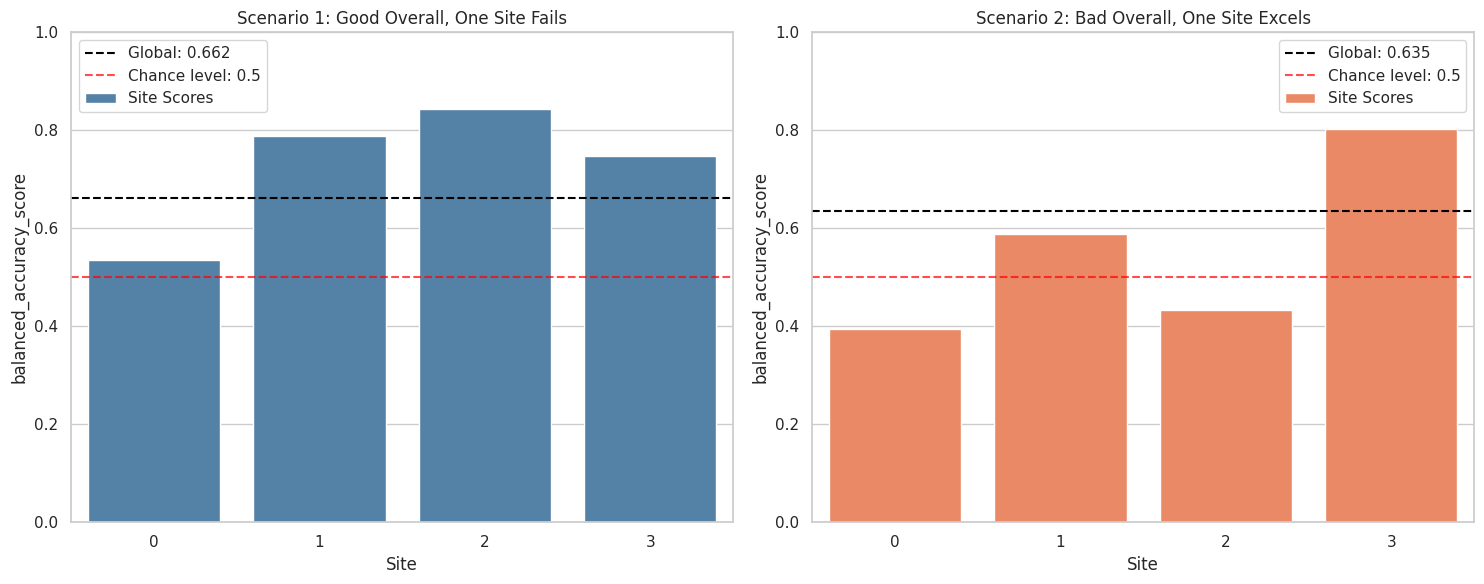

In [7]:
sites_unique = np.unique(sites)

# Visualize both scenarios
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scenario 1
site_scores_s1 = [metric_s1[metric_to_plot][s] for s in sites_unique]

sns.barplot(
    x=sites_unique,
    y=site_scores_s1,
    color="steelblue",
    label="Site Scores",
    ax=axes[0],
)
axes[0].axhline(
    metric_global_s1,
    color="black",
    linestyle="--",
    label=f"Global: {metric_global_s1:.3f}",
)
axes[0].axhline(
    0.5,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Chance level: 0.5",
)
axes[0].set_xlabel("Site")
axes[0].set_ylabel(metric_to_plot)
axes[0].set_title("Scenario 1: Good Overall, One Site Fails")
axes[0].legend()
axes[0].grid(True, alpha=1, axis="y")
axes[0].set_ylim([0, 1])

# Scenario 2
site_scores_s2 = [metric_s2[metric_to_plot][s] for s in sites_unique]
sns.barplot(
    x=sites_unique,
    y=site_scores_s2,
    color="coral",
    label="Site Scores",
    ax=axes[1],
)
axes[1].axhline(
    metric_global_s2,
    color="black",
    linestyle="--",
    label=f"Global: {metric_global_s2:.3f}",
)
axes[1].axhline(
    0.5,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Chance level: 0.5",
)
axes[1].set_xlabel("Site")
axes[1].set_ylabel(metric_to_plot)
axes[1].set_title("Scenario 2: Bad Overall, One Site Excels")
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

### As expected, the performance of the **bad** sites is near to chance.

### Question

- How is it possible that they have an similar overall performance?
- In this example, no EoS were used simulated. What do you think it could happen if different EoS are presented in different sites?

### Solution

You can check the solutions of this notebook [here](https://github.com/N-Nieto/OHBM2026_Educational_course_harmonization/tree/main/solutions/block03)